# Прогноз возраста абалона

EDA → расширение признаков → Multi-Layer Perceptron с подбором гиперпараметров и визуализациями остатков/важности признаков.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")
SEED = 42
DATA_PATH = Path("data.csv")

In [2]:
raw_df = pd.read_csv(DATA_PATH)
raw_df = raw_df.rename(
    columns={
        "Whole weight.1": "Shucked weight",
        "Whole weight.2": "Viscera weight",
    }
)
raw_df["Age"] = raw_df["Rings"] + 1.5
print(raw_df.shape)
raw_df.head()

(90615, 11)


,id,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11,12.5
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11,12.5
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6,7.5
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10,11.5
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9,10.5


In [3]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    enriched = df.copy()
    eps = 1e-6
    enriched["Volume"] = (
        enriched["Length"] * enriched["Diameter"] * enriched["Height"]
    )
    enriched["Height_to_Length"] = enriched["Height"] / (enriched["Length"] + eps)
    enriched["Diameter_to_Length"] = enriched["Diameter"] / (enriched["Length"] + eps)
    enriched["Shell_to_Whole"] = enriched["Shell weight"] / (enriched["Whole weight"] + eps)
    enriched["Viscera_to_Whole"] = enriched["Viscera weight"] / (enriched["Whole weight"] + eps)
    enriched["Shucked_to_Whole"] = enriched["Shucked weight"] / (enriched["Whole weight"] + eps)
    enriched["Density"] = enriched["Whole weight"] / (enriched["Volume"] + eps)
    enriched["Mass_per_Length"] = enriched["Whole weight"] / (enriched["Length"] + eps)
    enriched["Shell_mass_per_Length"] = enriched["Shell weight"] / (enriched["Length"] + eps)
    derived = [
        "Volume",
        "Height_to_Length",
        "Diameter_to_Length",
        "Shell_to_Whole",
        "Viscera_to_Whole",
        "Shucked_to_Whole",
        "Density",
        "Mass_per_Length",
        "Shell_mass_per_Length",
    ]
    enriched[derived] = enriched[derived].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return enriched


def compute_permutation_mae(model, X, y, *, n_repeats=5, random_state=SEED):
    rng = np.random.default_rng(random_state)
    baseline = mean_absolute_error(y, model.predict(X))
    X_perm = X.copy()
    importances = []
    for feature in X.columns:
        original = X[feature].to_numpy(copy=True)
        deltas = []
        for _ in range(n_repeats):
            shuffled = original.copy()
            rng.shuffle(shuffled)
            X_perm[feature] = shuffled
            mae = mean_absolute_error(y, model.predict(X_perm))
            deltas.append(mae - baseline)
        X_perm[feature] = original
        importances.append((feature, float(np.mean(deltas))))
    return (
        pd.DataFrame(importances, columns=["feature", "mae_increase"])
        .sort_values("mae_increase", ascending=False)
        .reset_index(drop=True)
    )


df = engineer_features(raw_df)
df.head()

,id,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings,Age,Volume,Height_to_Length,Diameter_to_Length,Shell_to_Whole,Viscera_to_Whole,Shucked_to_Whole,Density,Mass_per_Length,Shell_mass_per_Length
0,0,F,0.550,0.430,0.150,0.7715,0.3285,0.1465,0.2400,11,12.5,0.035475,0.272727,0.781817,0.311082,0.189890,0.425793,21.747097,1.402725,0.436363
1,1,F,0.630,0.490,0.145,1.1300,0.4580,0.2765,0.3200,11,12.5,0.044761,0.230158,0.777777,0.283186,0.244690,0.405309,25.244345,1.793648,0.507936
2,2,I,0.160,0.110,0.025,0.0210,0.0055,0.0030,0.0050,6,7.5,0.000440,0.156249,0.687496,0.238084,0.142850,0.261892,47.619048,0.131249,0.031250
3,3,M,0.595,0.475,0.150,0.9145,0.3755,0.2055,0.2500,10,11.5,0.042394,0.252100,0.798318,0.273373,0.224713,0.410606,21.571067,1.536972,0.420167
4,4,I,0.555,0.425,0.130,0.7820,0.3695,0.1600,0.1975,9,10.5,0.030664,0.234234,0.765764,0.252557,0.204603,0.472506,25.501594,1.409006,0.355855


In [4]:
print("Shape:", df.shape)
print("\nMissing values:")
display(df.isna().sum())
print("\nAge statistics:")
display(df["Age"].describe())

Shape: (90615, 20)

Missing values:


id                       0
Sex                      0
Length                   0
Diameter                 0
Height                   0
Whole weight             0
Shucked weight           0
Viscera weight           0
Shell weight             0
Rings                    0
Age                      0
Volume                   0
Height_to_Length         0
Diameter_to_Length       0
Shell_to_Whole           0
Viscera_to_Whole         0
Shucked_to_Whole         0
Density                  0
Mass_per_Length          0
Shell_mass_per_Length    0
dtype: int64


Age statistics:


count    90615.000000
mean        11.196794
std          3.176221
min          2.500000
25%          9.500000
50%         10.500000
75%         12.500000
max         30.500000
Name: Age, dtype: float64

In [5]:
sex_share = df["Sex"].value_counts(normalize=True).mul(100).round(2)
print("Sex distribution, %")
display(sex_share)

numeric_cols = df.select_dtypes(include=["number"]).columns.drop("Age")
corr = df[numeric_cols].corrwith(df["Age"]).sort_values(ascending=False)
print("Top correlations with Age")
display(corr.head(15))

Sex distribution, %


Sex
I    36.52
M    34.24
F    29.24
Name: proportion, dtype: float64

Top correlations with Age


Rings                    1.000000
Shell_mass_per_Length    0.731731
Shell weight             0.694766
Height                   0.665772
Mass_per_Length          0.644432
Diameter                 0.636832
Volume                   0.624044
Length                   0.623786
Whole weight             0.617274
Viscera weight           0.588954
Shucked weight           0.515067
Height_to_Length         0.398611
Diameter_to_Length       0.365053
Shell_to_Whole           0.140695
id                       0.000938
dtype: float64

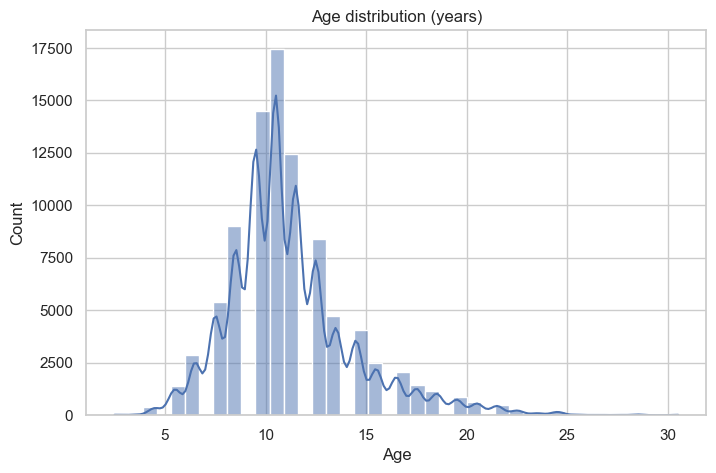

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Age"], bins=40, kde=True, color="#4C72B0")
plt.title("Age distribution (years)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

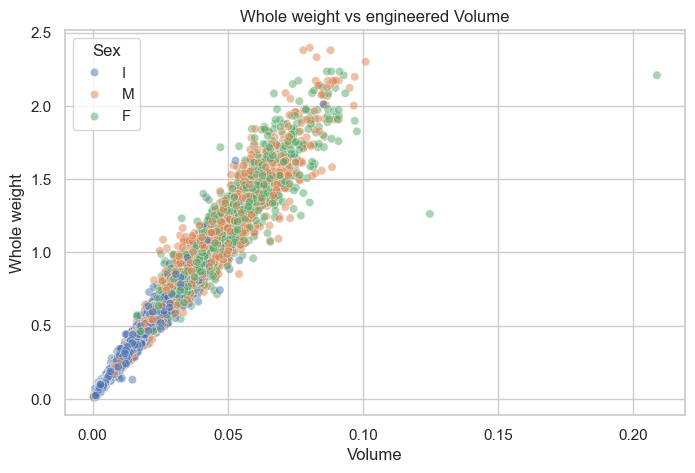

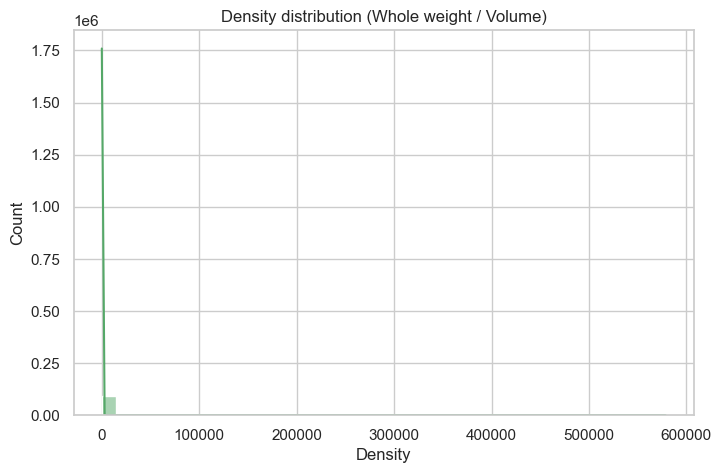

In [7]:
sample = df.sample(n=min(5000, len(df)), random_state=SEED)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=sample,
    x="Volume",
    y="Whole weight",
    hue="Sex",
    alpha=0.5,
)
plt.title("Whole weight vs engineered Volume")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(df["Density"], bins=40, kde=True, color="#55A868")
plt.title("Density distribution (Whole weight / Volume)")
plt.show()

In [8]:
features = df.drop(columns=["Age", "Rings", "id"])
target = df["Age"]
numeric_features = features.select_dtypes(include=["number"]).columns.tolist()
categorical_features = features.select_dtypes(include=["object", "category"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=SEED,
    stratify=pd.qcut(target, q=10, duplicates="drop"),
)
len(X_train), len(X_test)

(72492, 18123)

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

mlp = MLPRegressor(
    random_state=SEED,
    solver="adam",
    max_iter=250,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.15,
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", mlp),
    ]
)

param_grid = {
    "model__hidden_layer_sizes": [(64, 32), (96, 48)],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [1e-4, 1e-3],
    "model__learning_rate_init": [0.001],
    "model__batch_size": [128],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2,
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

top_configs = (
    pd.DataFrame(grid.cv_results_)
    .sort_values("rank_test_score")
    .head(5)[
        [
            "rank_test_score",
            "mean_test_score",
            "param_model__hidden_layer_sizes",
            "param_model__activation",
            "param_model__alpha",
            "param_model__batch_size",
        ]
    ]
)
top_configs

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best params: {'model__activation': 'tanh', 'model__alpha': 0.0001, 'model__batch_size': 128, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.001}
Best CV MAE: 1.2592818967816755


,rank_test_score,mean_test_score,param_model__hidden_layer_sizes,param_model__activation,param_model__alpha,param_model__batch_size
4,1,-1.259282,"(64, 32)",tanh,0.0001,128
5,2,-1.262029,"(96, 48)",tanh,0.0001,128
6,3,-1.262792,"(64, 32)",tanh,0.0010,128
2,4,-1.263528,"(64, 32)",relu,0.0010,128
7,5,-1.263692,"(96, 48)",tanh,0.0010,128


In [10]:
best_model = grid.best_estimator_
preds = best_model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R^2: {r2:.4f}")

residuals = y_test - preds
residuals.describe()

Test MAE: 1.2500
Test RMSE: 1.8730
Test R^2: 0.6512


count    18123.000000
mean         0.033204
std          1.872773
min        -10.573066
25%         -0.944847
50%         -0.215090
75%          0.674450
max         16.242657
Name: Age, dtype: float64

In [11]:
importance_df = compute_permutation_mae(
    best_model, X_test, y_test, n_repeats=5, random_state=SEED
)
importance_df.head(15)

,feature,mae_increase
0,Shell weight,0.266080
1,Shell_mass_per_Length,0.233676
2,Shucked_to_Whole,0.216343
3,Shucked weight,0.184119
4,Length,0.178591
5,Mass_per_Length,0.134886
6,Height,0.122535
7,Diameter,0.084503
8,Volume,0.062944
9,Sex,0.058678


C:\Users\Dnec\AppData\Local\Temp\ipykernel_17176\1283137834.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


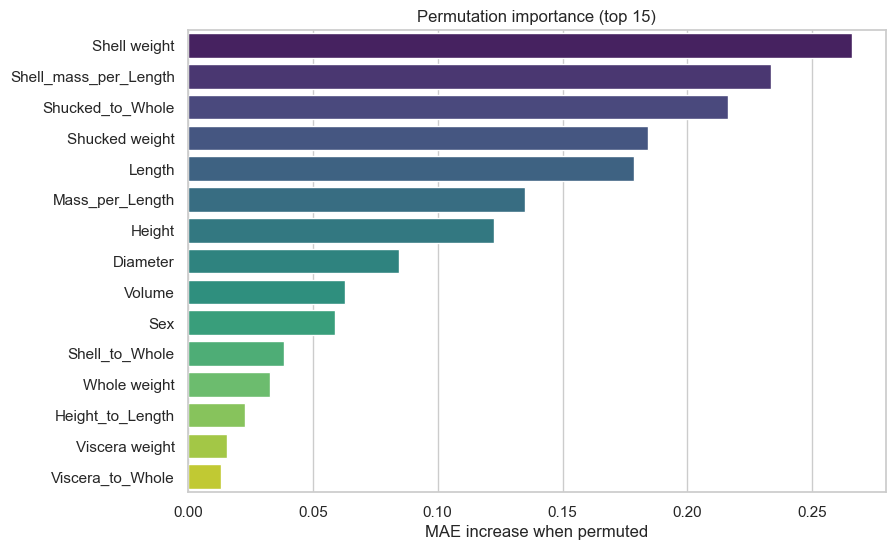

In [12]:
plt.figure(figsize=(9, 6))
sns.barplot(
    data=importance_df.head(15),
    x="mae_increase",
    y="feature",
    palette="viridis",
)
plt.xlabel("MAE increase when permuted")
plt.ylabel("")
plt.title("Permutation importance (top 15)")
plt.show()

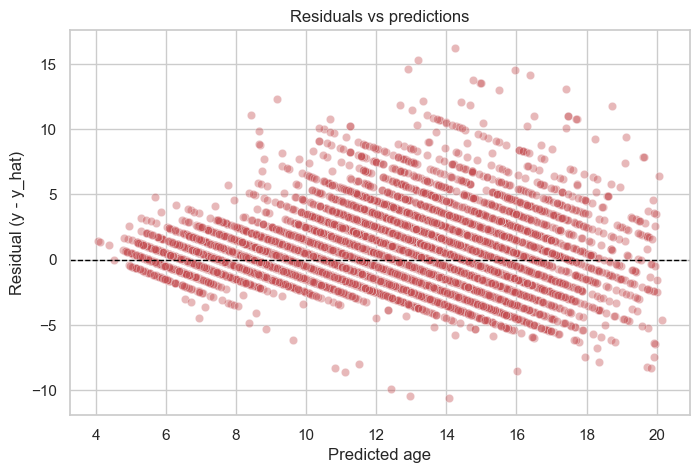

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=preds, y=residuals, alpha=0.4, color="#C44E52")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Predicted age")
plt.ylabel("Residual (y - y_hat)")
plt.title("Residuals vs predictions")
plt.show()